In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

df.head()

Saving Day15_Executive_Hotel_Booking_EDA_Dataset.csv to Day15_Executive_Hotel_Booking_EDA_Dataset.csv


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (25180, 35)

Column Names:
['Booking_ID', 'Hotel_Type', 'Hotel_Location', 'Booking_Date', 'Arrival_Date', 'Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights', 'Adults', 'Children', 'Babies', 'Country', 'Market_Segment', 'Distribution_Channel', 'Is_Repeated_Guest', 'Previous_Cancellations', 'Previous_Bookings', 'Room_Type_Reserved', 'Room_Type_Assigned', 'Booking_Changes', 'Deposit_Type', 'Agent_ID', 'Company_ID', 'Days_In_Waiting_List', 'Customer_Type', 'Meal_Type', 'Total_Nights', 'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests', 'Satisfaction_Score', 'Reservation_Status', 'Is_Canceled', 'Reservation_Status_Date', 'Estimated_Revenue']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type      

In [4]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Hotel_Location          106
Children                121
Country                 466
Agent_ID                304
Company_ID            20729
Meal_Type               245
ADR                      82
Satisfaction_Score      164
dtype: int64


In [5]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

,0
Company_ID,82.323272
Country,1.850675
Agent_ID,1.207307
Meal_Type,0.972994
Satisfaction_Score,0.651311
Children,0.480540
Hotel_Location,0.420969
ADR,0.325655


In [6]:
print("Duplicate Records:", df.duplicated().sum())


Duplicate Records: 180


In [7]:
date_columns = [
    "Booking_Date",
    "Arrival_Date",
    "Reservation_Status_Date"
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

df[date_columns].dtypes

,0
Booking_Date,datetime64[ns]
Arrival_Date,datetime64[ns]
Reservation_Status_Date,datetime64[ns]


In [8]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts(dropna=False).head(20))


 Booking_ID
Booking_ID
HTL014830    2
HTL004101    2
HTL013750    2
HTL016178    2
HTL021917    2
HTL006580    2
HTL006602    2
HTL021212    2
HTL011270    2
HTL006082    2
HTL024938    2
HTL008682    2
HTL004882    2
HTL001507    2
HTL008013    2
HTL012383    2
HTL008397    2
HTL008608    2
HTL019213    2
HTL023170    2
Name: count, dtype: int64

 Hotel_Type
Hotel_Type
City Hotel      15606
Resort Hotel     9454
CITY HOTEL         44
city hotel         43
City hotel         33
Name: count, dtype: int64

 Hotel_Location
Hotel_Location
Dubai        3171
Lisbon       3168
London       3130
Barcelona    3082
Amsterdam    3055
Goa          1966
Algarve      1920
Bali         1893
Maldives     1857
Phuket       1828
NaN           106
Unknown         4
Name: count, dtype: int64

 Country
Country
BRA    1158
NLD    1119
ESP    1113
SWE    1109
ITA    1107
NOR    1103
CHN    1101
JPN    1095
GBR    1088
DNK    1078
SAU    1076
ARE    1070
PRT    1065
FRA    1062
CAN    1059
IND    1054
USA   

In [9]:
df.describe()

,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Company_ID,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
count,25180,25180,25180.000000,25180.000000,25180.000000,25180.000000,25059.000000,25180.000000,25180.000000,25180.000000,...,4451.000000,25180.000000,25180.000000,25098.000000,25180.000000,25180.000000,25016.000000,25180.000000,25180,25180.000000
mean,2024-12-31 23:59:18.824463360,2025-07-02 03:21:55.901509120,182.200556,1.240429,2.451072,2.198967,0.372122,0.043050,0.172597,0.038642,...,1059.135700,1.561438,3.693090,140.628124,0.228753,1.097458,3.854402,0.721763,2025-07-03 23:34:26.211278592,535.495478
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1001.000000,0.000000,1.000000,30.800000,0.000000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000
25%,2024-06-30 18:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,1029.000000,0.000000,2.000000,105.620000,0.000000,0.000000,3.590000,0.000000,2025-01-01 00:00:00,230.540000
50%,2024-12-30 00:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,1059.000000,0.000000,4.000000,134.425000,0.000000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,1088.000000,1.000000,5.000000,169.097500,0.000000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.577500
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.000000,7.000000,6.000000,2.000000,1.000000,3.000000,...,1119.000000,180.000000,45.000000,710.500000,3.000000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000
std,NaN,NaN,105.604452,1.063802,2.031003,0.662379,0.657811,0.225057,0.377906,0.251403,...,34.270543,4.459498,2.085623,47.808034,0.530060,1.047671,0.405110,0.448140,NaN,389.700003


In [10]:
df["Children"] = df["Children"].fillna(df["Children"].median())

In [11]:
df["Agent_ID"] = df["Agent_ID"].fillna(0)
df["Company_ID"] = df["Company_ID"].fillna(0)

In [12]:
numeric_columns = [
    "Lead_Time_Days",
    "Weekend_Nights",
    "Weekday_Nights",
    "Adults",
    "Children",
    "Babies",
    "Previous_Cancellations",
    "Previous_Bookings",
    "Booking_Changes",
    "Days_In_Waiting_List",
    "Total_Nights",
    "ADR",
    "Required_Car_Parking_Spaces",
    "Total_Special_Requests",
    "Satisfaction_Score",
    "Estimated_Revenue"
]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[column] < lower) | (df[column] > upper)).sum()

    print(column, ":", outliers)

Lead_Time_Days : 2
Weekend_Nights : 0
Weekday_Nights : 144
Adults : 7586
Children : 212
Babies : 965
Previous_Cancellations : 692
Previous_Bookings : 4346
Booking_Changes : 1287
Days_In_Waiting_List : 4108
Total_Nights : 137
ADR : 359
Required_Car_Parking_Spaces : 4570
Total_Special_Requests : 0
Satisfaction_Score : 249
Estimated_Revenue : 659


In [13]:
df["Arrival_Year"] = df["Arrival_Date"].dt.year
df["Arrival_Month"] = df["Arrival_Date"].dt.month_name()

df["Booking_Year"] = df["Booking_Date"].dt.year

df["Total_Guests"] = (
    df["Adults"] +
    df["Children"] +
    df["Babies"]
)

df["Cancellation_Rate"] = df["Is_Canceled"] * 100

df.head()

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Arrival_Year,Arrival_Month,Booking_Year,Total_Guests,Cancellation_Rate
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,4.37,No-Show,1,2025-07-07,714.65,2025,July,2024,2.0,100
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,3.63,Canceled,1,2025-02-09,377.43,2025,February,2024,4.0,100
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,3.70,Check-Out,0,2024-06-20,296.06,2024,June,2024,4.0,0
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,3.18,Check-Out,0,2024-04-08,333.63,2024,April,2024,2.0,0
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,3.79,Check-Out,0,2025-06-01,230.50,2025,May,2024,4.0,0


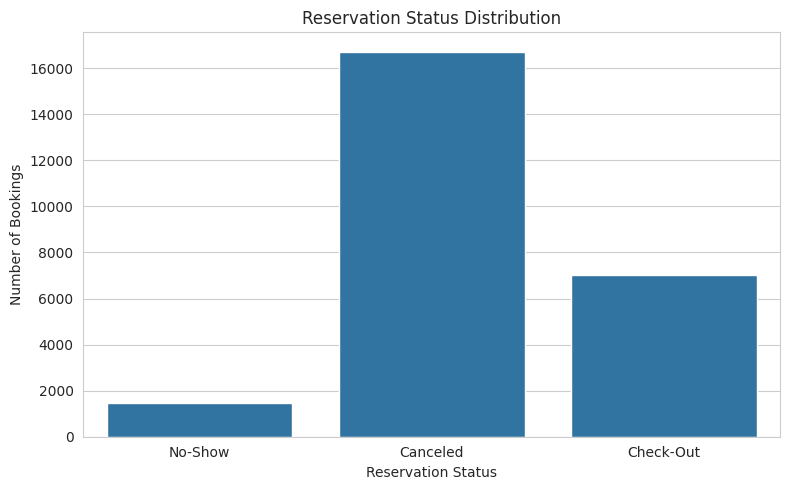

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Reservation_Status"
)

plt.title("Reservation Status Distribution")
plt.xlabel("Reservation Status")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

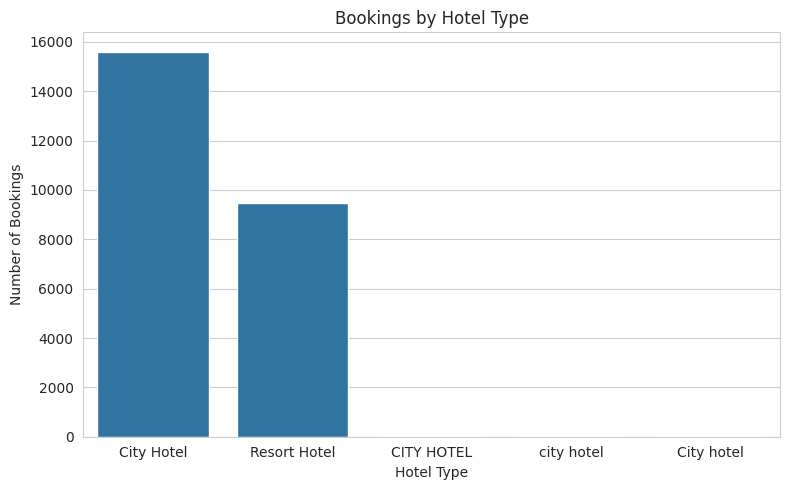

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Hotel_Type"
)

plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

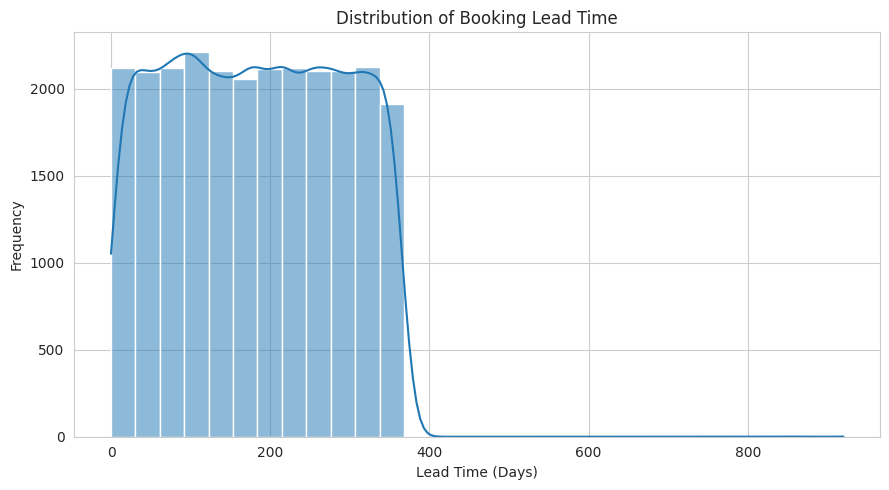

In [16]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Lead_Time_Days",
    bins=30,
    kde=True
)

plt.title("Distribution of Booking Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

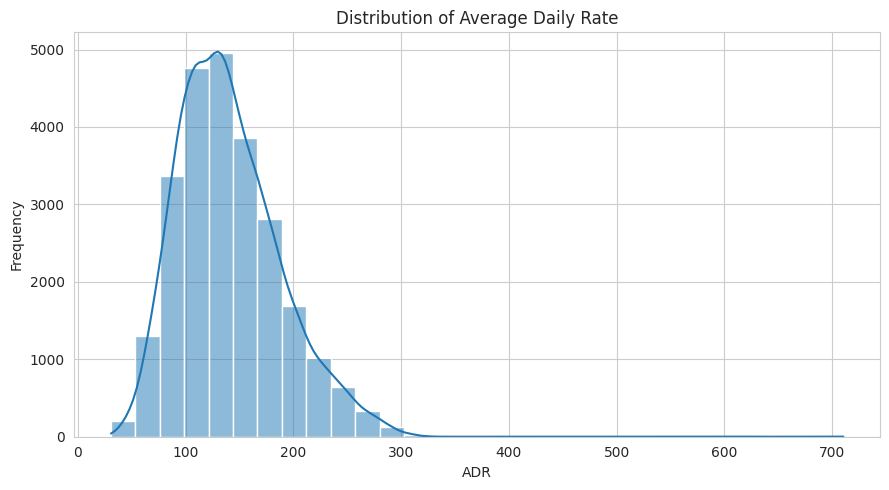

In [17]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="ADR",
    bins=30,
    kde=True
)

plt.title("Distribution of Average Daily Rate")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

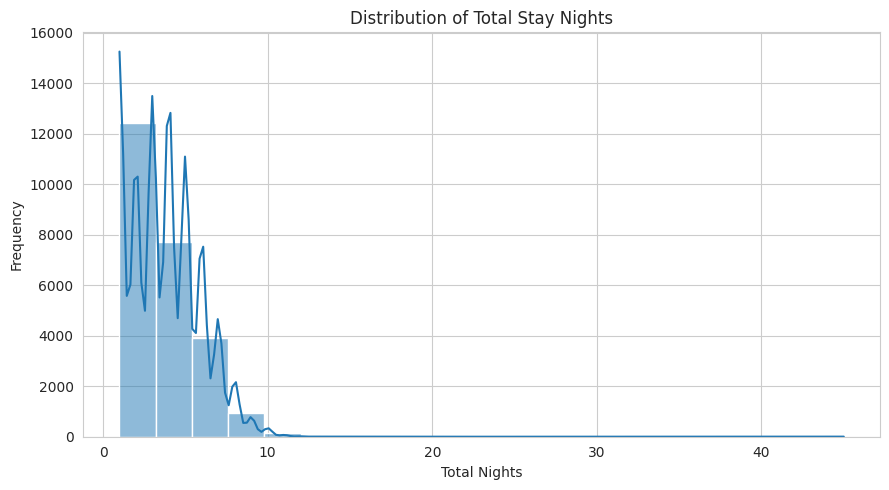

In [18]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Total_Nights",
    bins=20,
    kde=True
)

plt.title("Distribution of Total Stay Nights")
plt.xlabel("Total Nights")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

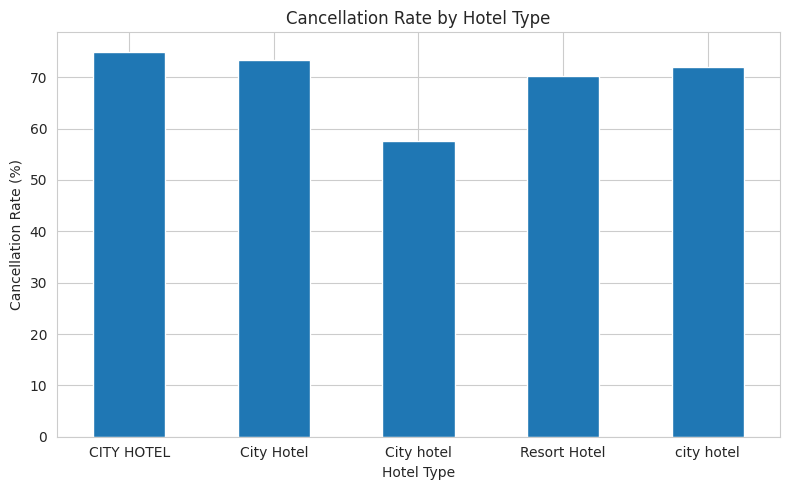

In [19]:
cancellation_hotel = df.groupby("Hotel_Type")["Is_Canceled"].mean() * 100

plt.figure(figsize=(8, 5))

cancellation_hotel.plot(kind="bar")

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

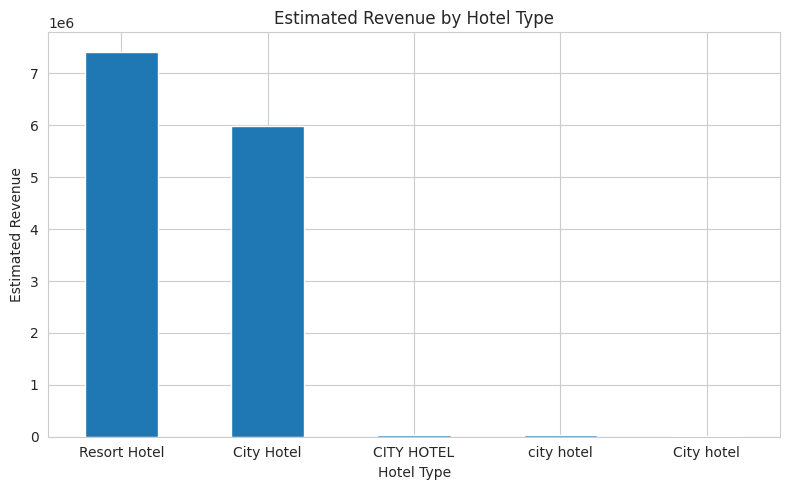

In [20]:
revenue_hotel = df.groupby("Hotel_Type")["Estimated_Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

revenue_hotel.plot(kind="bar")

plt.title("Estimated Revenue by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Estimated Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

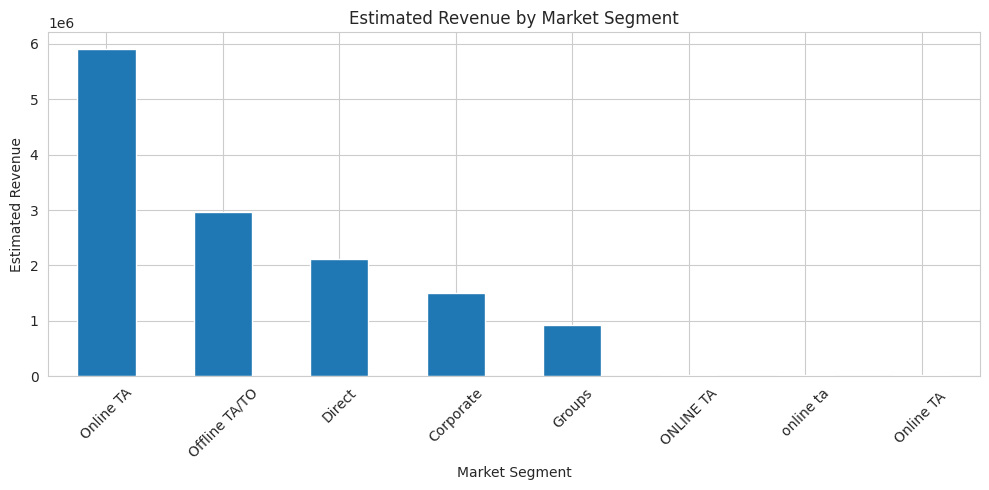

In [21]:
segment_revenue = df.groupby("Market_Segment")["Estimated_Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

segment_revenue.plot(kind="bar")

plt.title("Estimated Revenue by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Estimated Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

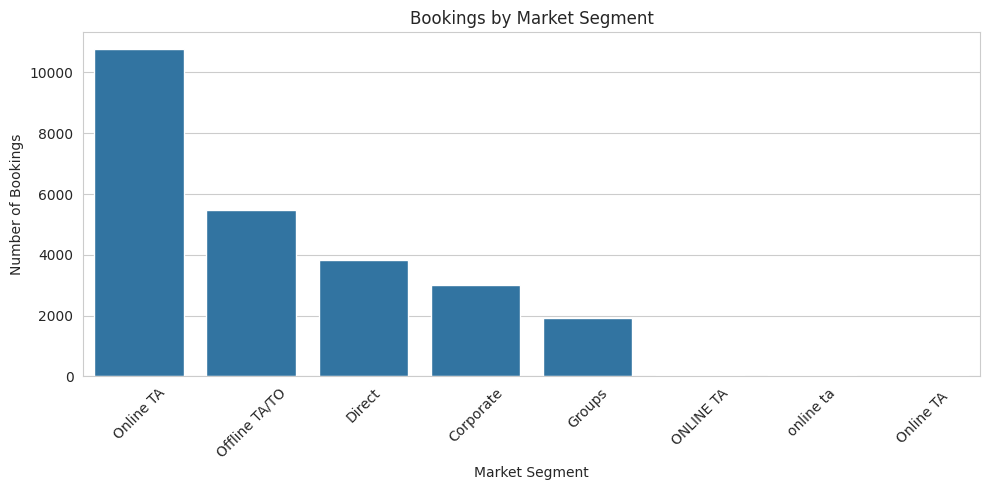

In [22]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Market_Segment",
    order=df["Market_Segment"].value_counts().index
)

plt.title("Bookings by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

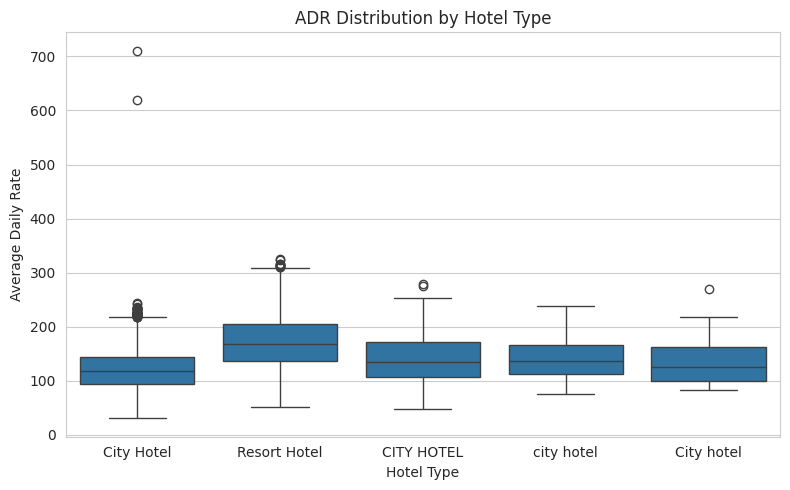

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Hotel_Type",
    y="ADR"
)

plt.title("ADR Distribution by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate")
plt.tight_layout()
plt.show()

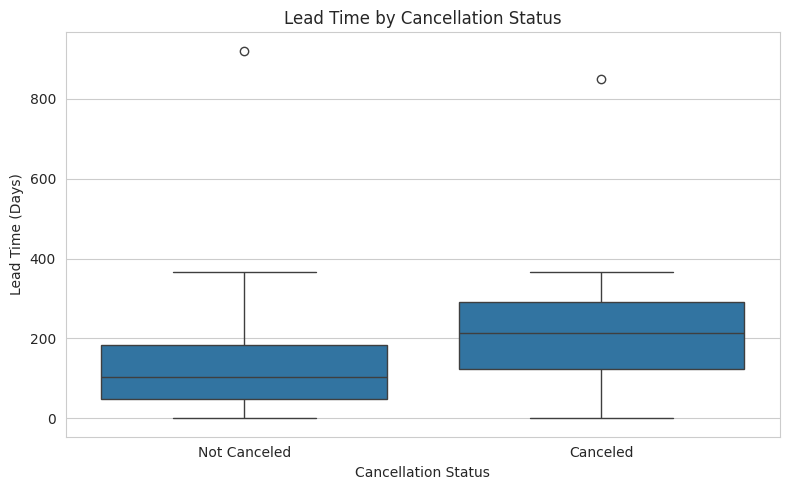

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Is_Canceled",
    y="Lead_Time_Days"
)

plt.title("Lead Time by Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Lead Time (Days)")
plt.xticks([0, 1], ["Not Canceled", "Canceled"])
plt.tight_layout()
plt.show()

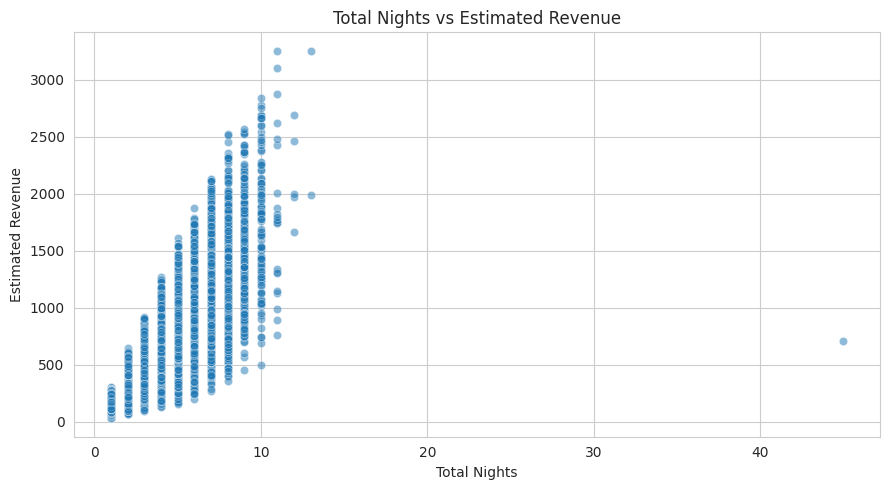

In [25]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Total_Nights",
    y="Estimated_Revenue",
    alpha=0.5
)

plt.title("Total Nights vs Estimated Revenue")
plt.xlabel("Total Nights")
plt.ylabel("Estimated Revenue")
plt.tight_layout()
plt.show()

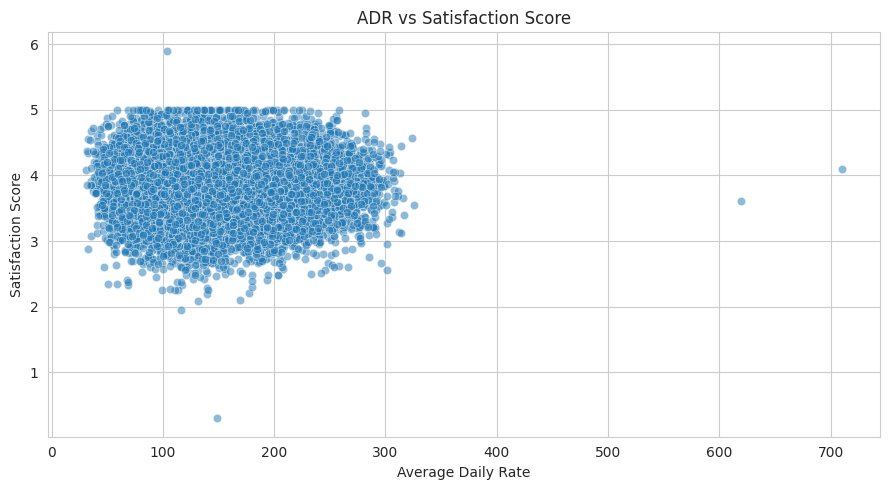

In [26]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="ADR",
    y="Satisfaction_Score",
    alpha=0.5
)

plt.title("ADR vs Satisfaction Score")
plt.xlabel("Average Daily Rate")
plt.ylabel("Satisfaction Score")
plt.tight_layout()
plt.show()

In [27]:
customer_type = df.groupby("Customer_Type").agg({
    "Booking_ID": "count",
    "Estimated_Revenue": "sum",
    "Satisfaction_Score": "mean"
}).sort_values("Estimated_Revenue", ascending=False)

customer_type

,Booking_ID,Estimated_Revenue,Satisfaction_Score
Customer_Type,,,
Contract,6446,3486359.12,3.857485
Group,6328,3382655.52,3.851517
Transient-Party,6329,3336523.63,3.850165
Transient,6077,3278237.86,3.858557


In [28]:
room_analysis = df.groupby("Room_Type_Reserved").agg({
    "Booking_ID": "count",
    "Estimated_Revenue": "sum",
    "ADR": "mean"
}).sort_values("Estimated_Revenue", ascending=False)

room_analysis

,Booking_ID,Estimated_Revenue,ADR
Room_Type_Reserved,,,
H,3176,2333764.12,193.781301
G,3154,2098808.77,173.605500
F,3124,1867329.79,158.746764
E,3134,1730195.91,143.712308
D,3227,1585255.53,129.257149
C,3203,1418815.78,115.844571
B,2998,1235020.78,107.553097
A,3164,1214585.45,101.495214


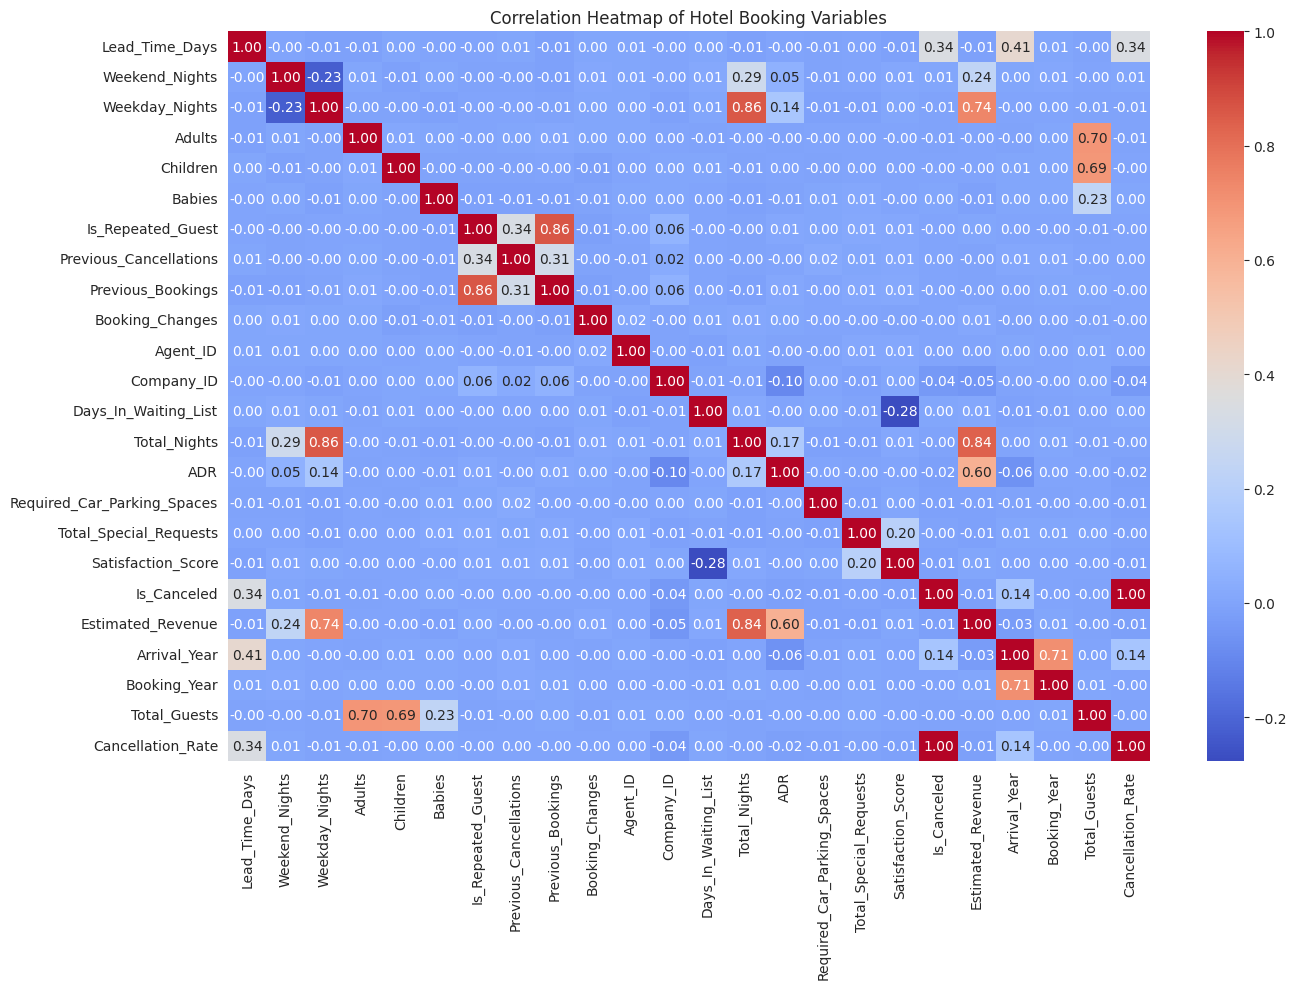

In [29]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Hotel Booking Variables")
plt.tight_layout()
plt.show()

## Key Business Insights

1. The dataset contains **25,180 hotel bookings**, with a very high **cancellation rate of 72.18%**, indicating a major opportunity to improve booking retention.

2. **Resort Hotels generated the highest estimated revenue**, contributing approximately **₹74.21 lakh**, making them the strongest hotel type in terms of revenue generation.

3. **Online Travel Agents (Online TA)** were the most important market segment, with **10,782 bookings** and the highest estimated revenue of approximately **₹59.08 lakh**.

4. **Total Nights and Estimated Revenue showed a strong positive correlation of 0.84**, indicating that longer stays are strongly associated with higher revenue.

5. **ADR and Estimated Revenue had a positive correlation of 0.60**, suggesting that higher average daily rates are generally associated with increased revenue. Lead Time and Cancellation also showed a positive correlation of **0.34**, indicating that longer booking lead times are moderately associated with cancellations.

## Management Recommendations

1. **Reduce the high cancellation rate** by introducing flexible cancellation policies, advance-booking incentives, and targeted retention campaigns.

2. **Strengthen partnerships with Online Travel Agents**, as this segment contributes the highest number of bookings and revenue.

3. **Promote longer stays** through weekly packages, discounts for extended bookings, and attractive stay bundles to increase overall revenue.

4. **Optimize room pricing and ADR** using demand-based pricing strategies while maintaining customer satisfaction.

5. **Develop targeted strategies for Resort Hotels**, as they generate the highest estimated revenue and represent a strong revenue opportunity.

6. **Monitor bookings with long lead times** and use reminders, confirmation campaigns, and incentives to reduce the likelihood of cancellations.

7. **Track key business metrics regularly**, including cancellation rate, ADR, total nights, revenue, market-segment performance, and customer satisfaction to support data-driven decision-making.
